# Defense A on SPML: third benchmark

Third pilot run of Defense A (input-classifier defense) on the SPML dataset (Signed Prompt Meta-Learning, 16,012 rows train split). Same model as the deepset and neuralchemy pilots (`ProtectAI/deberta-v3-base-prompt-injection-v2`) and same wrapper (`src/defense_a/deberta.py`).

**Sampling**: 1,000 SAFE + 1,000 INJECTION stratified subsample from the full 16,012-row train split (3,470 SAFE / 12,542 INJECTION), seed 42. The full-distribution imbalance (78% injection) is not preserved in this subsample by design: balanced sampling gives a cleaner read on precision/recall without the majority-class trivial baseline dominating.

**Input to classifier**: `User Prompt` column only. `System Prompt` is internal agent context in the SPML framing; an input filter deployed at the user-turn boundary would not see it.

Inference is run by `scripts/run_defense_a_spml.py` and cached at `cache/defense_a_deberta_spml.jsonl`; this notebook only does analysis.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc,
    average_precision_score,
)
from dotenv import load_dotenv

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / '.git').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

load_dotenv(REPO_ROOT / '.env')

from src.cache import load_records

RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
CACHE_PATH  = REPO_ROOT / 'cache' / 'defense_a_deberta_spml.jsonl'
SAMPLE_PATH = RESULTS_DIR / 'spml_sample_2k.parquet'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

# Token presence check
TOKEN_NAMES = ['HF_TOKEN', 'GROQ_API_KEY', 'ANTHROPIC_API_KEY', 'OPENAI_API_KEY']
for tok in TOKEN_NAMES:
    status = 'SET' if os.environ.get(tok) else 'MISSING'
    print(f'{tok}: {status}')

HF_TOKEN: SET
GROQ_API_KEY: SET
ANTHROPIC_API_KEY: SET
OPENAI_API_KEY: SET


In [2]:
sample = pd.read_parquet(SAMPLE_PATH)
print(f'sample rows: {len(sample)}')
print('label balance:', sample['Prompt injection'].value_counts().to_dict())
print('columns:', sample.columns.tolist())
print('Degree value counts (injection rows only):')
print(sample[sample['Prompt injection'] == 1]['Degree'].value_counts().sort_index().to_dict())

sample rows: 2000
label balance: {1: 1000, 0: 1000}
columns: ['System Prompt', 'User Prompt', 'Prompt injection', 'Degree', 'Source', 'prompt_idx']
Degree value counts (injection rows only):
{1: 195, 2: 124, 3: 201, 4: 142, 5: 207, 7: 71, 10: 60}


In [3]:
preds = pd.DataFrame(load_records(CACHE_PATH))
preds = preds.rename(columns={'label': 'pred_label', 'label_id': 'pred_label_id', 'score': 'pred_score'})
results = sample.merge(preds, on='prompt_idx', how='inner')
assert len(results) == len(sample), f'expected {len(sample)} merged rows, got {len(results)} (cache may be incomplete)'
results.to_csv(RESULTS_DIR / 'defense_a_spml.csv', index=False)
print(f'saved {RESULTS_DIR / "defense_a_spml.csv"}')

saved C:\git_projects\capstone_prompt_injection\results\defense_a_spml.csv


## Headline metrics

In [4]:
y_true  = results['Prompt injection'].values
y_pred  = results['pred_label_id'].values
y_score = results['injection_score'].values

rng = np.random.default_rng(RANDOM_SEED)
# Subsample is balanced (50/50), so majority class is arbitrary; use INJECTION for consistency.
p_inj = float(np.mean(y_true))
y_majority = np.ones_like(y_true)   # always-INJECTION baseline
y_random   = rng.binomial(n=1, p=p_inj, size=len(y_true))

def metric_row(name, y_t, y_p):
    p, r, f1, _ = precision_recall_fscore_support(y_t, y_p, average='binary', pos_label=1, zero_division=0)
    return {'model': name, 'accuracy': accuracy_score(y_t, y_p), 'precision': p, 'recall': r, 'f1': f1}

rows = [
    metric_row('DeBERTa v3 (ProtectAI v2)', y_true, y_pred),
    metric_row('Majority class (always INJECTION)', y_true, y_majority),
    metric_row('Random (stratified, seed 42)', y_true, y_random),
]
metrics_df = pd.DataFrame(rows)
for c in ['accuracy', 'precision', 'recall', 'f1']:
    metrics_df[c] = metrics_df[c].round(4)
metrics_df.to_csv(RESULTS_DIR / 'defense_a_spml_metrics.csv', index=False)
metrics_df

,model,accuracy,precision,recall,f1
0,DeBERTa v3 (ProtectAI v2),0.9515,0.9154,0.995,0.9535
1,Majority class (always INJECTION),0.5000,0.5000,1.000,0.6667
2,"Random (stratified, seed 42)",0.5140,0.5141,0.510,0.5120


In [5]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
ap = average_precision_score(y_true, y_score)
print(f'ROC AUC: {roc_auc:.4f}, AP: {ap:.4f}')
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

ROC AUC: 0.9978, AP: 0.9972
Confusion matrix [[TN, FP], [FN, TP]]:
[[908  92]
 [  5 995]]


## ROC and PR curves

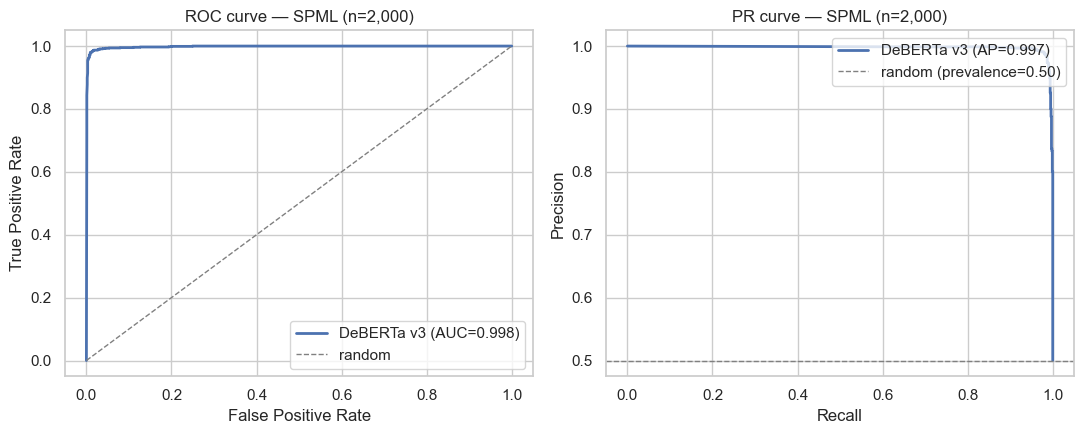

In [6]:
from sklearn.metrics import precision_recall_curve

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, lw=2, label=f'DeBERTa v3 (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — SPML (n=2,000)')
ax.legend(loc='lower right')

# PR
ax = axes[1]
ax.plot(rec_curve, prec_curve, lw=2, label=f'DeBERTa v3 (AP={ap:.3f})')
ax.axhline(p_inj, ls='--', color='gray', lw=1, label=f'random (prevalence={p_inj:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR curve — SPML (n=2,000)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'defense_a_spml_roc_pr.png', dpi=150)
plt.show()

## Confusion matrix

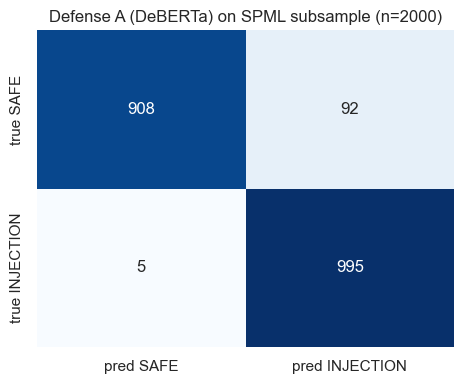

In [7]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.8, 4.0))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['pred SAFE', 'pred INJECTION'],
    yticklabels=['true SAFE', 'true INJECTION'],
    ax=ax,
)
ax.set_title(f'Defense A (DeBERTa) on SPML subsample (n={len(results)})')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'defense_a_spml_confusion.png', dpi=150)
plt.show()

## Threshold sweep

Score-zero rate among injections: 0.002  (deepset ~0.40, neuralchemy ~0.07)
F1-optimal threshold: 0.999  ->  F1=0.979
Default threshold (0.5)           ->  F1=0.954
Lift from threshold tuning: +0.026 F1


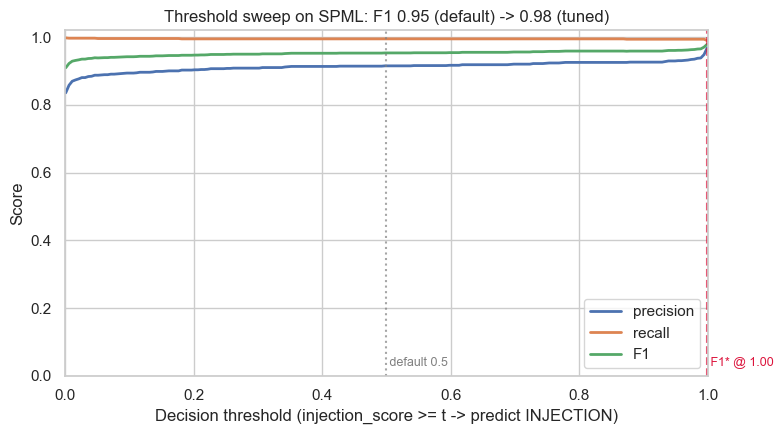

In [8]:
thresholds = np.linspace(0.001, 0.999, 200)
prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    yp_t = (y_score >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, yp_t, average='binary', pos_label=1, zero_division=0
    )
    prec_t.append(p); rec_t.append(r); f1_t.append(f)
prec_t = np.array(prec_t); rec_t = np.array(rec_t); f1_t = np.array(f1_t)

best_idx   = int(np.argmax(f1_t))
best_t     = float(thresholds[best_idx])
best_f1    = float(f1_t[best_idx])
default_f1 = float(f1_t[np.argmin(np.abs(thresholds - 0.5))])

zero_score_among_inj = float((results.loc[results['Prompt injection'] == 1, 'injection_score'] < 0.001).mean())
print(f'Score-zero rate among injections: {zero_score_among_inj:.3f}  (deepset ~0.40, neuralchemy ~0.07)')
print(f'F1-optimal threshold: {best_t:.3f}  ->  F1={best_f1:.3f}')
print(f'Default threshold (0.5)           ->  F1={default_f1:.3f}')
print(f'Lift from threshold tuning: +{(best_f1 - default_f1):.3f} F1')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, prec_t, lw=2, label='precision')
ax.plot(thresholds, rec_t,  lw=2, label='recall')
ax.plot(thresholds, f1_t,   lw=2, label='F1')
ax.axvline(0.5, ls=':', color='gray', alpha=0.7)
ax.text(0.5, 0.02, ' default 0.5', color='gray', va='bottom', ha='left', fontsize=9)
ax.axvline(best_t, ls='--', color='crimson', alpha=0.7)
ax.text(best_t, 0.02, f' F1* @ {best_t:.2f}', color='crimson', va='bottom', ha='left', fontsize=9)
ax.set_xlabel('Decision threshold (injection_score >= t -> predict INJECTION)')
ax.set_ylabel('Score')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title(f'Threshold sweep on SPML: F1 {default_f1:.2f} (default) -> {best_f1:.2f} (tuned)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'defense_a_spml_threshold_sweep.png', dpi=150)
plt.show()

## Recall by Degree (injection severity)

SPML labels each injection row with a `Degree` value (severity). Decomposing recall by Degree shows whether the classifier's misses are concentrated at low-severity attacks (expected, consistent with weak signal) or high-severity ones (more concerning).

 Degree   n  recall
      1 195   0.985
      2 124   0.992
      3 201   1.000
      4 142   1.000
      5 207   0.995
      7  71   1.000
     10  60   1.000


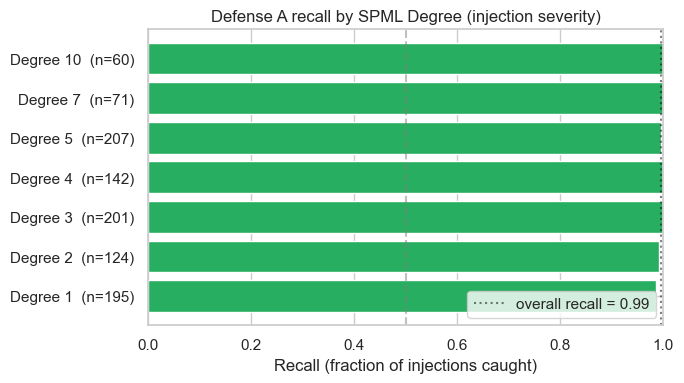

In [9]:
inj = results[results['Prompt injection'] == 1].copy()
inj['caught'] = (inj['pred_label_id'] == 1).astype(int)

by_degree = (
    inj.groupby('Degree')
       .agg(n=('caught', 'size'), recall=('caught', 'mean'))
       .reset_index()
       .sort_values('Degree')
)
by_degree['recall'] = by_degree['recall'].round(3)
by_degree.to_csv(RESULTS_DIR / 'defense_a_spml_by_degree.csv', index=False)
print(by_degree.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.0))
colors = [
    '#c0392b' if r < 0.5 else ('#e67e22' if r < 0.75 else '#27ae60')
    for r in by_degree['recall']
]
labels = [
    f'Degree {int(d)}  (n={n})'
    for d, n in zip(by_degree['Degree'], by_degree['n'])
]
ax.barh(labels, by_degree['recall'], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel('Recall (fraction of injections caught)')
ax.set_title('Defense A recall by SPML Degree (injection severity)')
ax.axvline(0.5, color='gray', ls='--', alpha=0.5)
overall_recall = float(metrics_df.iloc[0]['recall'])
ax.axvline(overall_recall, color='black', ls=':', alpha=0.5,
           label=f'overall recall = {overall_recall:.2f}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'defense_a_spml_degree_recall.png', dpi=150)
plt.show()

## Cross-dataset comparison

In [10]:
deepset_metrics = pd.read_csv(RESULTS_DIR / 'defense_a_deepset_metrics.csv').iloc[0]
neuro_metrics   = pd.read_csv(RESULTS_DIR / 'defense_a_neuralchemy_metrics.csv').iloc[0]
spml_metrics    = metrics_df.iloc[0]

compare = pd.DataFrame([
    {'dataset': 'deepset (n=546)',      **{k: deepset_metrics[k] for k in ['accuracy','precision','recall','f1']}},
    {'dataset': f'neuralchemy (n=4391)',**{k: neuro_metrics[k]   for k in ['accuracy','precision','recall','f1']}},
    {'dataset': 'SPML (n=2000)',        **{k: spml_metrics[k]    for k in ['accuracy','precision','recall','f1']}},
])
compare['roc_auc'] = [0.8811, 0.9713, round(roc_auc, 4)]
compare.to_csv(RESULTS_DIR / 'defense_a_cross_dataset.csv', index=False)
compare

,dataset,accuracy,precision,recall,f1,roc_auc
0,deepset (n=546),0.7802,0.9560,0.4286,0.5918,0.8811
1,neuralchemy (n=4391),0.9037,0.9827,0.8555,0.9147,0.9713
2,SPML (n=2000),0.9515,0.9154,0.9950,0.9535,0.9978


## Summary

Artifacts:
- `results/spml_sample_2k.parquet`
- `results/defense_a_spml.csv`
- `results/defense_a_spml_metrics.csv`
- `results/defense_a_spml_by_degree.csv`
- `results/defense_a_cross_dataset.csv`
- `results/figures/defense_a_spml_roc_pr.png`
- `results/figures/defense_a_spml_confusion.png`
- `results/figures/defense_a_spml_threshold_sweep.png`
- `results/figures/defense_a_spml_degree_recall.png`

Caveats: balanced subsample (50/50) rather than natural SPML prevalence (78% injection). Default-threshold metrics. No Meta Prompt Guard 2. Not the frozen eval set.